## Implementacija modela za klasifikaciju tekstra

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    RocCurveDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from sklearn.model_selection import StratifiedKFold


In [ ]:
df = pd.read_csv(
    "C:\\Users\\gala.posedi\\Desktop\\fakultet\\Media-analysis\\training.csv",
    sep=";",
    encoding="utf-8-sig")

print("Dimenzije baze:")
print(df.shape)

print("\nKolone:")
print(df.columns.tolist())

print("\nPrvih 5 redova:")
display(df.head())

print("\nTipovi podataka:")
print(df.dtypes)

print("\nNedostajuće vrednosti:")
print(df.isnull().sum())

Dimenzije baze:
(4154, 3)

Kolone:
['article_id', 'source', 'full_text']

Prvih 5 redova:


,article_id,source,full_text
0,2017,N1,(intervju) živković: predložio sam formiranje ...
1,3949,Nova,video studenti pomogli bivšem srpskom reprezen...
2,2554,Nova,blog studentska pobuna uživo na rts: podrška s...
3,1490,Danas,studenti u blokadi apelovali da univerzitet u ...
4,584,Blic,studenti u blokadi organizuju skup podrške rek...



Tipovi podataka:
article_id     int64
source        object
full_text     object
dtype: object

Nedostajuće vrednosti:
article_id    0
source        0
full_text     0
dtype: int64


Pošto je kolona article_id nevažna kolona za buduće implementacije modela, izbacićemo je.

In [5]:
df = df.drop(columns="article_id")
df.head

<bound method NDFrame.head of         source                                          full_text
0           N1  (intervju) živković: predložio sam formiranje ...
1         Nova  video studenti pomogli bivšem srpskom reprezen...
2         Nova  blog studentska pobuna uživo na rts: podrška s...
3        Danas  studenti u blokadi apelovali da univerzitet u ...
4         Blic  studenti u blokadi organizuju skup podrške rek...
...        ...                                                ...
4149     Kurir  "skandalozno i sramotno koga tajkunski mediji ...
4150  Politika  blokaderi ponižavaju radnika koji čisti smeće ...
4151      Blic  studenti i danas blokirali saobraćajnice na 15...
4152      Nova  grošelj: zahtevi studenata su zahtevi koje bi ...
4153     Danas  od 14 državnih fakulteta u nišu u blokadi je j...

[4154 rows x 2 columns]>

Sada ćemo učitati i test skup radi kasnije evaluacije modela.

In [9]:
df_test = pd.read_csv(
    "C:\\Users\\gala.posedi\\Desktop\\fakultet\\Media-analysis\\test.csv",
    sep=";",
    encoding="utf-8-sig"

).drop(columns="article_id")

df_test.head()

,source,full_text
0,Danas,studenti iz niša pozvali na protest podrške de...
1,Blic,"studenti kod inženjerske komore srbije, pružil..."
2,Danas,„sad ili nikad – vladaće večno“: profesor među...
3,N1,nove brojke: od 1. novembra protesti u 240 nas...
4,Blic,tužilac marković podržao najavu vučića da pomi...


In [14]:
df["source"].value_counts()

source
Nova        1332
Politika     897
Danas        715
Blic         612
N1           423
Kurir        175
Name: count, dtype: int64

Na osnovu kolone `source` člancima se dodeljuje binarna oznaka: **Nova, N1 i Danas** dobijaju labelu `1` (privrženiji studentskim demostracijama), dok ostali izvori dobijaju `0`. Na ovaj način formira se ciljna promenljiva `label` koja će se koristiti za treniranje klasifikacionog modela.

In [16]:
klasa1_sources = ["Nova", "N1", "Danas"]

df["label"] = df["source"].isin(klasa1_sources).astype(int)

df[["source", "label"]].head()

,source,label
0,N1,1
1,Nova,1
2,Nova,1
3,Danas,1
4,Blic,0


Kako smo videli ranije, skup članaka je dosta nebalansiran, pa ćemo implementirati dve metode: UnderSampling i OverSampling.

In [ ]:
X = df["full_text"]
y = df["label"]

tfidf = TfidfVectorizer( max_features=10000, ngram_range=(1, 2))

X_tfidf = tfidf.fit_transform(X)

print("Dimenzije podataka nakon TF-IDF vektorizacije:")
print(X_tfidf.shape)

Dimenzije podataka nakon TF-IDF vektorizacije:
(4154, 10000)


In [18]:
under_sampler = RandomUnderSampler(random_state=42)

X_under, y_under = under_sampler.fit_resample(X_tfidf, y)

print("Originalna raspodela:")
print(y.value_counts())

print("\nRaspodela nakon undersamplinga:")
print(y_under.value_counts())

print("\nDimenzije undersampled skupa:")
print(X_under.shape)

Originalna raspodela:
label
1    2470
0    1684
Name: count, dtype: int64

Raspodela nakon undersamplinga:
label
0    1684
1    1684
Name: count, dtype: int64

Dimenzije undersampled skupa:
(3368, 10000)


In [19]:
over_sampler = RandomOverSampler(random_state=42)

X_over, y_over = over_sampler.fit_resample(X_tfidf, y)

print("Originalna raspodela:")
print(y.value_counts())

print("\nRaspodela nakon oversamplinga:")
print(y_over.value_counts())

print("\nDimenzije oversampled skupa:")
print(X_over.shape)

Originalna raspodela:
label
1    2470
0    1684
Name: count, dtype: int64

Raspodela nakon oversamplinga:
label
1    2470
0    2470
Name: count, dtype: int64

Dimenzije oversampled skupa:
(4940, 10000)


Sada ćemo implementirati običam SVM klasifikacioni model.
SVM klasifikator se trenira nad tri verzije trening skupa: originalnim, undersamplovanim i oversamplovanim podacima. Svi modeli se evaluiraju na istom test skupu pomoću matrice konfuzije i mera kao što su accuracy, precision, recall i F1-score.

In [ ]:
df_test["label"] = (
    df_test["source"]
    .isin(klasa1_sources)
    .astype(int))

X_test = df_test["full_text"]
y_test = df_test["label"]

X_test_tfidf = tfidf.transform(X_test)


In [ ]:
svm_original = LinearSVC(C=1.0, random_state=42)

svm_original.fit(X_tfidf, y)

y_pred_original = svm_original.predict(X_test_tfidf)

In [31]:
print("SVM model sa orginalnim podacima")

print("Accuracy:",
      accuracy_score(y_test, y_pred_original))

print("Precision:",
      precision_score(y_test, y_pred_original))

print("Recall:",
      recall_score(y_test, y_pred_original))

print("F1-score:",
      f1_score(y_test, y_pred_original))

print("\nClassification report:")
print(classification_report(y_test, y_pred_original, target_names=["klasa 0", "klasa 1"])
)

SVM model sa orginalnim podacima
Accuracy: 0.9076034648700674
Precision: 0.9264705882352942
Recall: 0.9174757281553398
F1-score: 0.9219512195121952

Classification report:
              precision    recall  f1-score   support

     klasa 0       0.88      0.89      0.89       421
     klasa 1       0.93      0.92      0.92       618

    accuracy                           0.91      1039
   macro avg       0.90      0.91      0.90      1039
weighted avg       0.91      0.91      0.91      1039



SVM - UNDERSAMPLING
Accuracy: 0.9056785370548605
Precision: 0.9513888888888888
Recall: 0.8867313915857605
F1-score: 0.9179229480737019

Classification report:
                 precision    recall  f1-score   support

Antiblokaderski       0.85      0.93      0.89       421
    Blokaderski       0.95      0.89      0.92       618

       accuracy                           0.91      1039
      macro avg       0.90      0.91      0.90      1039
   weighted avg       0.91      0.91      0.91      1039



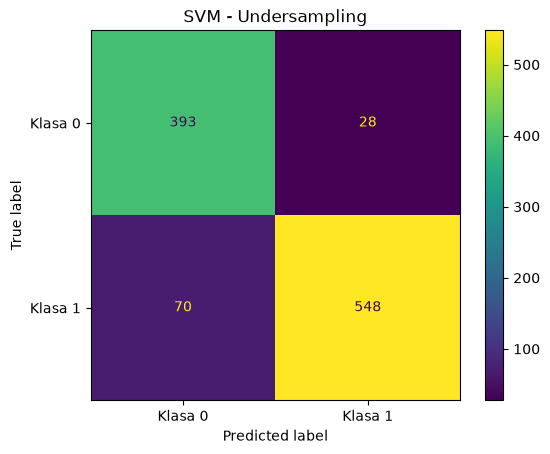

In [ ]:
svm_under = LinearSVC(C=1.0,random_state=42)

svm_under.fit(X_under, y_under)
y_pred_under = svm_under.predict(X_test_tfidf)


print("SVM - UNDERSAMPLING")

print("Accuracy:", accuracy_score(y_test, y_pred_under))
print("Precision:", precision_score(y_test, y_pred_under))
print("Recall:", recall_score(y_test, y_pred_under))
print("F1-score:", f1_score(y_test, y_pred_under))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred_under,
        target_names=["Antiblokaderski", "Blokaderski"]
    )
)

# Matrica konfuzije
cm_under = confusion_matrix(y_test, y_pred_under)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_under,
    display_labels=["Klasa 0", "Klasa 1"]
)

disp.plot()
plt.title("SVM - Undersampling")
plt.show()

SVM - OVERSAMPLING
Accuracy: 0.9066410009624639
Precision: 0.9305785123966942
Recall: 0.9110032362459547
F1-score: 0.9206868356500408

Classification report:
              precision    recall  f1-score   support

     Klasa 0       0.87      0.90      0.89       421
     Klasa 1       0.93      0.91      0.92       618

    accuracy                           0.91      1039
   macro avg       0.90      0.91      0.90      1039
weighted avg       0.91      0.91      0.91      1039



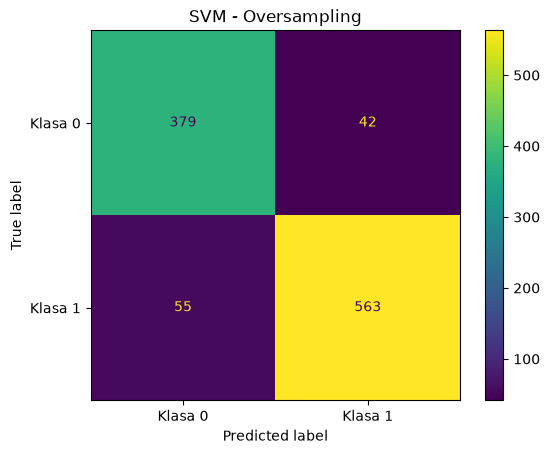

In [73]:
svm_over = LinearSVC(C=1.0,random_state=42)

svm_over.fit(X_over, y_over)
y_pred_over = svm_over.predict(X_test_tfidf)


print("SVM - OVERSAMPLING")
print("Accuracy:", accuracy_score(y_test, y_pred_over))
print("Precision:", precision_score(y_test, y_pred_over))
print("Recall:", recall_score(y_test, y_pred_over))
print("F1-score:", f1_score(y_test, y_pred_over))

print("\nClassification report:")
print(classification_report(y_test, y_pred_over,target_names=["Klasa 0", "Klasa 1"]))


# Matrica konfuzije
cm_over = confusion_matrix(y_test, y_pred_over)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_over,
    display_labels=["Klasa 0", "Klasa 1"]
)

disp.plot()
plt.title("SVM - Oversampling")
plt.show()

SVM - Original AUC: 0.9720
SVM - Oversampling AUC: 0.9721
SVM - Undersampling AUC: 0.9707


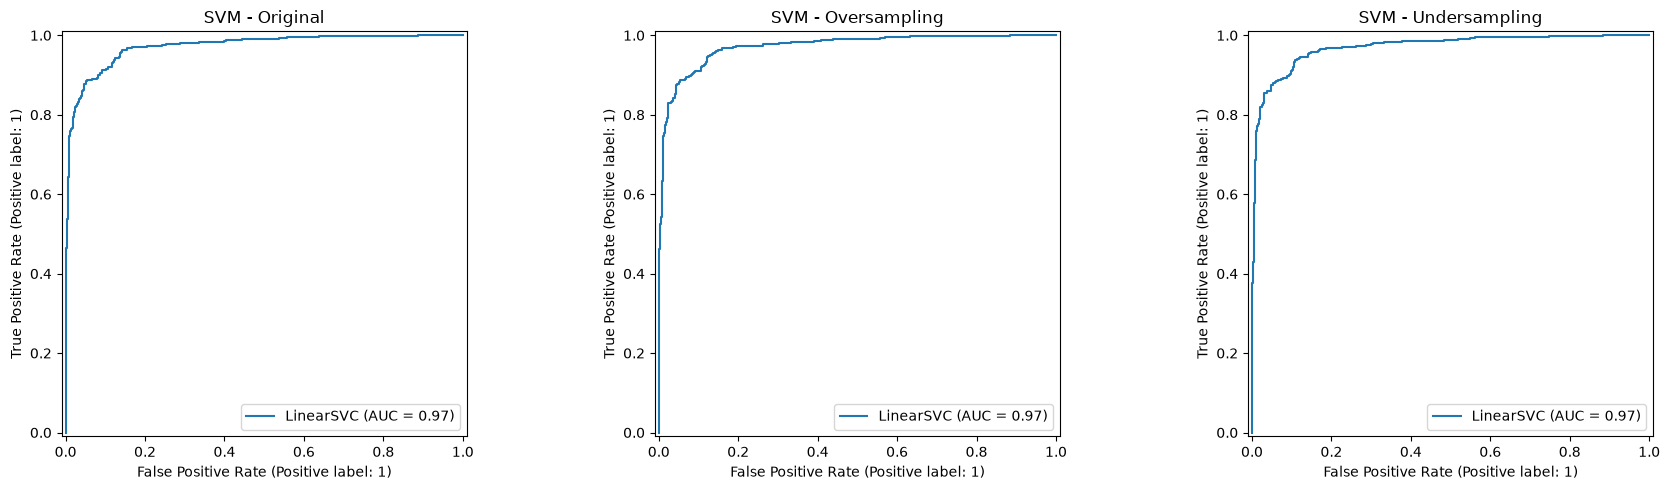

In [75]:
models = [("SVM - Original", svm_original),
          ("SVM - Oversampling", svm_over),
          ("SVM - Undersampling", svm_under)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models):

    roc_display = RocCurveDisplay.from_estimator(
        model,
        X_test_tfidf,
        y_test,
        ax=ax
    )
    ax.set_title(name)
    print(f"{name} AUC: {roc_display.roc_auc:.4f}")

plt.tight_layout()
plt.show()

Sada ćemo implementirati rekurentnu neuronsku LSTM mrežu, koja je pogodna sa radom sa tekstualnim podacima u svrhu klasifikacije modela.

In [ ]:
def tokenize(text):
    return str(text).lower().split()

train_tokens = [
    tokenize(text)
    for text in df["full_text"]
]

word_counts = Counter()

for tokens in train_tokens:
    word_counts.update(tokens)

vocab = { "<PAD>": 0, "<UNK>": 1}

for word, count in word_counts.items():

    if count >= 2:
        vocab[word] = len(vocab)


vocab_size = len(vocab)

print("Veličina rečnika:", vocab_size)

Veličina rečnika: 62149


In [47]:
MAX_LENGTH = 150

def encode_text(text):

    tokens = tokenize(text)
    indices = [vocab.get(word, vocab["<UNK>"])
        for word in tokens ]
    indices = indices[:MAX_LENGTH]

    if len(indices) < MAX_LENGTH:
        indices += [vocab["<PAD>"]] * (
            MAX_LENGTH - len(indices)
        )

    return indices

In [48]:
X_train_tensor = torch.tensor([encode_text(text) for text in df["full_text"]], dtype=torch.long)
y_train_tensor = torch.tensor(df["label"].values,dtype=torch.long)

X_test_tensor = torch.tensor([encode_text(text) for text in df_test["full_text"]],dtype=torch.long)
y_test_tensor = torch.tensor(df_test["label"].values, dtype=torch.long)

print("Train shape:", X_train_tensor.shape)
print("Test shape:", X_test_tensor.shape)

Train shape: torch.Size([4154, 150])
Test shape: torch.Size([1039, 150])


In [49]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [50]:
#RNN LSTM

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_classes
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        x = self.embedding(x)
        output, (hidden, cell) = self.lstm(x)
        x = hidden[-1]
        x = self.classifier(x)
        return x

Putem kros-validacije ćemo odlučiti koji skup parametara je najbolji za treniranje ovoh RNN-a.

In [51]:
def train_and_validate(
    train_loader,
    val_loader,
    embedding_dim,
    hidden_size,
    learning_rate,
    num_epochs=5
):

    model = LSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_size=hidden_size,
        num_classes=2
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()


    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            y_pred = torch.argmax(outputs, dim=1)
            predictions.extend(y_pred.cpu().numpy())
            true_labels.extend(y_batch.cpu().numpy())

    return f1_score(true_labels, predictions)

In [ ]:
full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [54]:
embedding_dims = [64, 128]
hidden_sizes = [32, 64]
learning_rates = [0.0005]

results = []
from torch.utils.data import Subset

for embedding_dim in embedding_dims:
    for hidden_size in hidden_sizes:
        for learning_rate in learning_rates:

            fold_scores = []

            for train_index, val_index in skf.split(X_train_tensor, y_train_tensor):

                train_subset = Subset(full_train_dataset,train_index)
                val_subset = Subset(full_train_dataset,val_index)


                train_loader_cv = DataLoader(train_subset, batch_size=64, shuffle=True)
                val_loader_cv = DataLoader(val_subset, batch_size=64, shuffle=False)

                score = train_and_validate(
                    train_loader_cv,
                    val_loader_cv,
                    embedding_dim=embedding_dim,
                    hidden_size=hidden_size,
                    learning_rate=learning_rate,
                    num_epochs=2
                )

                fold_scores.append(score)

            mean_f1 = np.mean(fold_scores)
            results.append({
                "embedding_dim":
                    embedding_dim,
                "hidden_size":
                    hidden_size,
                "learning_rate":
                    learning_rate,
                "mean_f1":
                    mean_f1
            })


            print(f"Embedding: {embedding_dim}, "
                f"Hidden: {hidden_size}, "
                f"LR: {learning_rate}, "
                f"Mean F1: {mean_f1:.4f}")

Embedding: 64, Hidden: 32, LR: 0.0005, Mean F1: 0.7288
Embedding: 64, Hidden: 64, LR: 0.0005, Mean F1: 0.7442
Embedding: 128, Hidden: 32, LR: 0.0005, Mean F1: 0.7174
Embedding: 128, Hidden: 64, LR: 0.0005, Mean F1: 0.7358


In [55]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="mean_f1", ascending=False)
results_df

,embedding_dim,hidden_size,learning_rate,mean_f1
1,64,64,0.0005,0.744195
3,128,64,0.0005,0.735757
0,64,32,0.0005,0.728817
2,128,32,0.0005,0.717437


In [56]:
best_params = results_df.iloc[0]

print("Najbolji parametri:")
print("Embedding dim:", best_params["embedding_dim"])
print("Hidden size:", best_params["hidden_size"])
print("Learning rate:", best_params["learning_rate"])
print("Mean CV F1:", best_params["mean_f1"])

Najbolji parametri:
Embedding dim: 64.0
Hidden size: 64.0
Learning rate: 0.0005
Mean CV F1: 0.7441951494470599


Sada kada smo dobili najbolje hiperparametre, pravimo finalni model sa tim parametrima, i testiramo ga na test skupu.

In [62]:
best_embedding_dim = int(best_params["embedding_dim"])
best_hidden_size = int(best_params["hidden_size"])
best_learning_rate = float(best_params["learning_rate"])

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=best_embedding_dim,
    hidden_size=best_hidden_size,
    num_classes=2
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)

In [63]:
#finalni DataLoader
final_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
final_train_loader = DataLoader(final_train_dataset, batch_size=32, shuffle=True)

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader
import numpy as np 

train_idx, val_idx = train_test_split(
    np.arange(len(y_train_tensor)),
    test_size=0.2,
    stratify=y_train_tensor.numpy(),
    random_state=42
)

train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=best_embedding_dim,
    hidden_size=best_hidden_size,
    num_classes=2
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)

num_epochs = 20

train_losses = []
val_losses = []
val_f1_scores = []

for epoch in range(num_epochs):


    final_model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    final_model.eval()

    running_val_loss = 0.0
    predictions = []
    true_labels = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = final_model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

            y_pred = torch.argmax(outputs, dim=1)
            predictions.extend(y_pred.cpu().numpy())
            true_labels.extend(y_batch.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)

    val_f1 = f1_score(true_labels, predictions)

    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f}")

Epoch 1/20 | Train Loss: 0.6802 | Val Loss: 0.6705 | Val F1: 0.7462
Epoch 2/20 | Train Loss: 0.6651 | Val Loss: 0.6690 | Val F1: 0.7475
Epoch 3/20 | Train Loss: 0.6457 | Val Loss: 0.6630 | Val F1: 0.7289
Epoch 4/20 | Train Loss: 0.6068 | Val Loss: 0.6555 | Val F1: 0.7061
Epoch 5/20 | Train Loss: 0.5618 | Val Loss: 0.6782 | Val F1: 0.5795
Epoch 6/20 | Train Loss: 0.6107 | Val Loss: 0.6874 | Val F1: 0.6125
Epoch 7/20 | Train Loss: 0.5737 | Val Loss: 0.6864 | Val F1: 0.6530
Epoch 8/20 | Train Loss: 0.5472 | Val Loss: 0.6930 | Val F1: 0.6602
Epoch 9/20 | Train Loss: 0.5185 | Val Loss: 0.7023 | Val F1: 0.6549
Epoch 10/20 | Train Loss: 0.4858 | Val Loss: 0.7153 | Val F1: 0.6500
Epoch 11/20 | Train Loss: 0.4452 | Val Loss: 0.7320 | Val F1: 0.6532
Epoch 12/20 | Train Loss: 0.3812 | Val Loss: 0.7491 | Val F1: 0.6930
Epoch 13/20 | Train Loss: 0.3280 | Val Loss: 0.7675 | Val F1: 0.6829
Epoch 14/20 | Train Loss: 0.2586 | Val Loss: 0.8151 | Val F1: 0.6968
Epoch 15/20 | Train Loss: 0.2111 | Val Loss

Sada, nakon biranja optimalnog broja epohi dobijena istom kros-validacijom, pravimo novi LSTM model, treniramo ga na celom originalnom trening skupu, i kasnije koristimo test skup za evaluaciju.

In [68]:
best_epoch = np.argmax(val_f1_scores) + 1

print("Najbolja epoha:", best_epoch)
print("Najbolji validation F1:", max(val_f1_scores))

final_model = LSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=best_embedding_dim,
    hidden_size=best_hidden_size,
    num_classes=2
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_learning_rate)

Najbolja epoha: 17
Najbolji validation F1: 0.7569573283858998


In [69]:
final_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
final_train_loader = DataLoader(final_train_dataset, batch_size=32, shuffle=True)

In [70]:
for epoch in range(best_epoch):

    final_model.train()
    running_loss = 0.0

    for X_batch, y_batch in final_train_loader:

        optimizer.zero_grad()
        outputs = final_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{best_epoch} | "
        f"Loss: {running_loss / len(final_train_loader):.4f}")

Epoch 1/17 | Loss: 0.6767
Epoch 2/17 | Loss: 0.6647
Epoch 3/17 | Loss: 0.6322
Epoch 4/17 | Loss: 0.5868
Epoch 5/17 | Loss: 0.5367
Epoch 6/17 | Loss: 0.4562
Epoch 7/17 | Loss: 0.3835
Epoch 8/17 | Loss: 0.3326
Epoch 9/17 | Loss: 0.3169
Epoch 10/17 | Loss: 0.2530
Epoch 11/17 | Loss: 0.2221
Epoch 12/17 | Loss: 0.1768
Epoch 13/17 | Loss: 0.1550
Epoch 14/17 | Loss: 0.2099
Epoch 15/17 | Loss: 0.1799
Epoch 16/17 | Loss: 0.2532
Epoch 17/17 | Loss: 0.1286


Finalno, sledi evaluacija modela.

In [72]:
final_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = final_model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(y_batch.cpu().numpy())

print("FINALNI LSTM MODEL")

print("Accuracy:", accuracy_score(all_labels,all_predictions))
print("Precision:",precision_score(all_labels, all_predictions))
print("Recall:", recall_score(all_labels, all_predictions))
print("F1-score:",f1_score(all_labels, all_predictions))
print("\nClassification report:")
print(classification_report(all_labels, all_predictions,target_names=["Klasa 0" , "Klasa 1"]))

FINALNI LSTM MODEL
Accuracy: 0.7151106833493744
Precision: 0.7280453257790368
Recall: 0.8317152103559871
F1-score: 0.7764350453172205

Classification report:
              precision    recall  f1-score   support

     Klasa 0       0.69      0.54      0.61       421
     Klasa 1       0.73      0.83      0.78       618

    accuracy                           0.72      1039
   macro avg       0.71      0.69      0.69      1039
weighted avg       0.71      0.72      0.71      1039



Sada ćemo implementirati i ROC krivu, i izračunati AUC, pa uporediti sa SVM modelima.

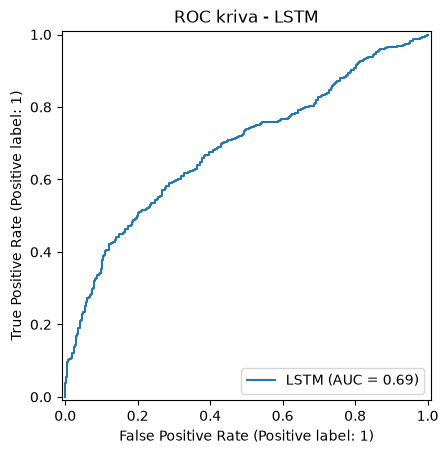

LSTM AUC: 0.6876


In [77]:
final_model.eval()

all_probabilities = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = final_model(X_batch)
        probabilities = torch.softmax(outputs,dim=1)[:, 1]
        all_probabilities.extend(probabilities.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

roc_display = RocCurveDisplay.from_predictions(
    all_labels,
    all_probabilities,
    name="LSTM"
)

plt.title("ROC kriva - LSTM")
plt.show()
print(f"LSTM AUC: {roc_display.roc_auc:.4f}")

SVM modeli su ostvarili značajno bolje rezultate od LSTM modela, sa vrednostima evaluacionih metrika oko 0.90 i AUC vrednošću oko 0.97, dok su kod LSTM modela metrike približno 0.70–0.80, a AUC oko 0.69. Jedan od mogućih razloga je relativno mali broj tekstova za treniranje neuronske mreže, zbog čega LSTM teže uči kvalitetne reprezentacije reči od početka. 

Sa druge strane, TF-IDF reprezentacija u kombinaciji sa linearnim SVM-om veoma dobro odgovara ovom problemu, jer efikasno prepoznaje razlike u zastupljenosti reči i fraza između dve klase. Rezultati zato pokazuju da složeniji model u ovom slučaju ne dovodi nužno do bolje klasifikacije.